# **1. Introduction:**

This internship focused on applying Natural Language Processing(**NLP**)techniques to analyze mental health related text data.      
Our goal was to develop an end-to-end **NLP** pipeline that can classify user statements into mental-health categories such as:           
(1)*Anxiety*  (2)*Stress*  (3)*Depression*  (4)*Bipolar Disorder*  (5)*Suicidal*  (6)*Personality Disorder*  (7)*Normal*   
The Project involved data cleaning, preprocessing, tokenization, embedding generation, sequence padding, and exploratory analysis.The final dataset is prepared for building deep learning models such as **BERT**, **LSTM**, or **Transformer-based classifiers**.

In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# 2. **Dataset Overview:**
  A dataset named Combined Data.csv containing 53,043 labeled text entries was used.
Each row includes:
  statement -> user text
  status -> mental-health category.          
  we can upload it in the google colab notebook.
  

In [ ]:
df=pd.read_csv("/content/Combined Data.csv")
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


# 3. **Text Preprocessing**    
Text preprocessing is an essential step in any NLP pipeline because raw text often contains noise such as punctuation, inconsistent casing, stopwords, and inflected word forms.To ensure that the model learns meaningful patterns, the text data must be cleaned and standardized.

In this step, We created a custom preprocessing function that performs the following operations:     
1. *Lowercasing*     
2. *Removing Special Characters*      
3. *Tokenization*             
4. *Stopword Removal*               
5. *Lemmatization*

In [ ]:
stop_words=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()

def preprocess_text(text):
  text=str(text)
  text=text.lower()
  text=re.sub(r"[^a-zA-Z0-9]"," ",text)
  tokens=nltk.word_tokenize(text)
  filtered=[word for word in tokens if word not in stop_words]
  lemmatized=[lemmatizer.lemmatize(word) for word in filtered]
  return " ".join(lemmatized)

# **These are the 'clean_text' outputs**

In [ ]:
df["clean_text"] = df["statement"].apply(preprocess_text)
df.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,shifted focus something else still worried
4,"I'm restless and restless, it's been a month n...",Anxiety,restless restless month boy mean


# **4. DistilBERT Tokenization and Embedding**                  

The project used DistilBERT (distilbert-base-uncased) for:
1. *Tokenization*

2. *Numerical conversion (input_ids)*

3. *768-dimensional sentence embedding extraction.*
So,here     


->Example Encoded Output

**Tokens: ['feeling', 'extremely', 'stressed', 'exam', 'b', 'tech']**

768-dimension vector extracted from the Classification token was used as the text embedding.
This step transforms raw text into meaningful numerical features for machine learning models.

In [ ]:
import transformers
from transformers import DistilBertTokenizer, DistilBertModel
tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model=DistilBertModel.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 5. **Bert Encode**
The bert_encode function serves as a crucial component in converting textual data into numerical representations suitable for machine learning models. It begins by taking a list of pre-processed tokens and reconstructs them into a complete sentence string. This sentence is then fed into a pre-trained DistilBERT tokenizer, which handles the conversion into numerical input IDs, along with necessary padding for shorter sequences and truncation for longer ones, ensuring all inputs conform to the model's expected length.

In [ ]:
import torch
def bert_encode(tokens):
  sentence = " ".join(tokens)
  encoded_input = tokenizer(sentence, return_tensors='pt', truncation=True, padding=True)
  with torch.no_grad():
    output = model(**encoded_input)

  embedding = output.last_hidden_state[:, 0, :].squeeze().numpy()
  return embedding

In [ ]:
text="I am feeling extremely stressed about my exams of B.Tech"
processed_text_string = preprocess_text(text)
tokens = processed_text_string.split()
bert_vector=bert_encode(tokens)

print("Tokens:",tokens)
print("Embedding size:",len(bert_vector))

Tokens: ['feeling', 'extremely', 'stressed', 'exam', 'b', 'tech']
Embedding size: 768


In [ ]:
bert_vector

array([-2.12008059e-02, -5.73016889e-02, -1.10688590e-01, -1.88890144e-01,
        1.08554512e-02, -3.02904189e-01,  4.26474452e-01,  5.39287984e-01,
       -1.42072752e-01, -2.42320031e-01, -4.96694222e-02,  1.94926523e-02,
        1.49947584e-01,  3.31135988e-01,  1.89267769e-01,  2.68000603e-01,
        2.80430943e-01,  1.46963596e-01,  1.12231821e-01, -2.18673080e-01,
       -2.68604122e-02, -3.76972944e-01,  1.66098341e-01,  1.39166802e-01,
        1.24052078e-01, -1.97320446e-01,  7.42470473e-02,  2.04027236e-01,
        8.54495615e-02, -1.29039824e-01, -5.96376397e-02,  2.53567677e-02,
       -6.39676973e-02,  9.90689620e-02,  7.27902949e-02,  3.64551581e-02,
        1.13407962e-01, -1.00010959e-03, -1.47972293e-02,  4.60451730e-02,
       -2.54509836e-01, -7.78922215e-02,  4.89744218e-03, -1.54687511e-02,
        9.34030570e-04, -2.61797994e-01, -2.12577796e+00, -1.99064031e-01,
       -1.18365258e-01, -2.90781170e-01,  4.94680911e-01,  2.36694828e-01,
        3.87232751e-02,  

**6. This is the function where we can convert a given text into it's numeric form**

In [ ]:
def numericConverter(text):
  processed_text_string = preprocess_text(text)
  tokens = processed_text_string.split()
  sent = " ".join(tokens)
  encoded = tokenizer(sent,return_tensors='pt',truncation=True,padding=True)
  return encoded['input_ids'].tolist()

**7. A text is taken from user as an input and the output is generated in the form of numerical representation**

In [ ]:
sample_text = input("Enter any text: ")
print(f"The numerical form is: { numericConverter(sample_text) }")

Enter any text: Pritam loves Priya
The numerical form is: [[101, 26927, 15464, 2293, 26927, 3148, 102]]


**8. pd.concat() function concatenates the two dataframes into a single data frame after cleaning the text feature field. The pd.concat() function is imported from the pandas library of python**

In [ ]:
new_df = pd.concat([df['clean_text'],df['status']],axis=1)

In [ ]:
new_df

,clean_text,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,shifted focus something else still worried,Anxiety
4,restless restless month boy mean,Anxiety
...,...,...
53038,nobody take seriously 24m dealt depression anx...,Anxiety
53039,selfishness feel good like belong world think ...,Anxiety
53040,way sleep better sleep night med help,Anxiety
53041,public speaking tip hi give presentation work ...,Anxiety


**9. The value Counts are generated to get the frequency of each unique class. It's required to visualize the class imbalance in the dataset**

In [ ]:
class_counts = df['status'].value_counts()
class_counts = dict(class_counts)
class_counts

{'Normal': np.int64(16351),
 'Depression': np.int64(15404),
 'Suicidal': np.int64(10653),
 'Anxiety': np.int64(3888),
 'Bipolar': np.int64(2877),
 'Stress': np.int64(2669),
 'Personality disorder': np.int64(1201)}

**10. Visualization of the Class Imbalance in the Dataset**



In [ ]:
x_set=[]
y_set=[]
for key,value in class_counts.items():
  x_set.append(key)
  y_set.append(value)
x_set

['Normal',
 'Depression',
 'Suicidal',
 'Anxiety',
 'Bipolar',
 'Stress',
 'Personality disorder']

In [ ]:
y_set


[np.int64(16351),
 np.int64(15404),
 np.int64(10653),
 np.int64(3888),
 np.int64(2877),
 np.int64(2669),
 np.int64(1201)]

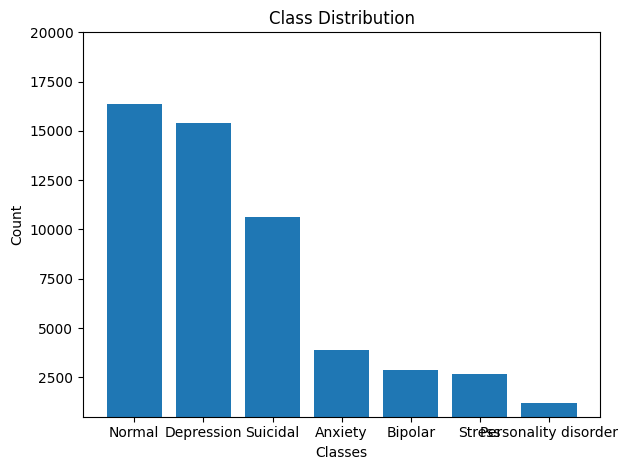

In [ ]:
import matplotlib.pyplot as plt
plt.bar(x_set,y_set)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.ylim(500,20000)
plt.tight_layout()
plt.figsize=(20,5)
plt.show()

**11. The numericConverter() function is applied on the 'clean_text' feature and updated in the same feature**

In [ ]:
df['clean_text'] = df['clean_text'].apply(numericConverter)

**12. The first 5 instances of the 'df' dataset show how the texts are converted into their numerical forms corresponding to each text of the 'statement' feature**

In [ ]:
df.head()

,statement,status,clean_text
0,oh my gosh,Anxiety,"[[101, 2821, 2175, 4095, 102]]"
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[[101, 4390, 5777, 5457, 2568, 15035, 2540, 86..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[[101, 3308, 2067, 6203, 2830, 4797, 2994, 150..."
3,I've shifted my focus to something else but I'...,Anxiety,"[[101, 5429, 3579, 2242, 2842, 2145, 5191, 102]]"
4,"I'm restless and restless, it's been a month n...",Anxiety,"[[101, 15035, 15035, 3204, 2879, 2812, 102]]"


**13. This cell is primarily responsible for padding the tokenized text sequences to a uniform length, which is a common preprocessing step before feeding text data into deep learning models.**


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = df['clean_text'].apply(lambda x: len(x[0]) if x and x[0] else 0).max()
tokens_to_pad = df['clean_text'].apply(lambda x: x[0] if x and x[0] else []).tolist()
padded_sequences = pad_sequences(tokens_to_pad, maxlen=max_len, padding='post', truncating='post')
p = type(padded_sequences)
df['clean_text_padded'] = list(padded_sequences)
df['clean_text_padded'].iloc[0].shape

(512,)

## **The 'df' dataset is shown after padding and those padded entities are kept into a seperate feature field given as 'clean_text_padded'**

In [ ]:
df.head()

,statement,status,clean_text,clean_text_padded
0,oh my gosh,Anxiety,"[[101, 2821, 2175, 4095, 102]]","[101, 2821, 2175, 4095, 102, 0, 0, 0, 0, 0, 0,..."
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"[[101, 4390, 5777, 5457, 2568, 15035, 2540, 86...","[101, 4390, 5777, 5457, 2568, 15035, 2540, 869..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"[[101, 3308, 2067, 6203, 2830, 4797, 2994, 150...","[101, 3308, 2067, 6203, 2830, 4797, 2994, 1503..."
3,I've shifted my focus to something else but I'...,Anxiety,"[[101, 5429, 3579, 2242, 2842, 2145, 5191, 102]]","[101, 5429, 3579, 2242, 2842, 2145, 5191, 102,..."
4,"I'm restless and restless, it's been a month n...",Anxiety,"[[101, 15035, 15035, 3204, 2879, 2812, 102]]","[101, 15035, 15035, 3204, 2879, 2812, 102, 0, ..."


# **14. In this dataset only two features are required to do the analysis.**
  **(1).'clean_text_padded'(Input)
     (2).'status'(Label)**


**Therefore both of those are concatenated using the pd.concat() function to get those into a single dataframe**

In [ ]:
new_df = pd.concat([df['clean_text_padded'],df['status']],axis=1)

# **This is the final dataset after preprocessing**

In [ ]:
new_df.head()

,clean_text_padded,status
0,"[101, 2821, 2175, 4095, 102, 0, 0, 0, 0, 0, 0,...",Anxiety
1,"[101, 4390, 5777, 5457, 2568, 15035, 2540, 869...",Anxiety
2,"[101, 3308, 2067, 6203, 2830, 4797, 2994, 1503...",Anxiety
3,"[101, 5429, 3579, 2242, 2842, 2145, 5191, 102,...",Anxiety
4,"[101, 15035, 15035, 3204, 2879, 2812, 102, 0, ...",Anxiety


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(new_df['clean_text_padded'],new_df['status'],test_size=0.2,random_state=42)

In [ ]:
X_train
X_test
y_train
y_test

,status
22261,Depression
41400,Depression
20065,Depression
30036,Normal
780,Normal
...,...
44519,Normal
47686,Depression
8092,Depression
26457,Depression


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.optimizers import Adam


X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_encoded, test_size=0.2, random_state=42
)
print("Data split into training and testing sets for CNN.")


vocab_size = np.max(X_cnn) + 1
embedding_dim = 100


model = Sequential([

    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=X_train_cnn.shape[1]),

    Conv1D(filters=128, kernel_size=5, activation='relu'),


    GlobalMaxPooling1D(),


    Dense(len(label_encoder.classes_), activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("1D CNN model built and compiled. Model Summary:")
model.summary()


history = model.fit(X_train_cnn, y_train_cnn, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
print("1D CNN model training complete.")


loss, accuracy = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\n1D CNN Test Loss: {loss:.4f}")
print(f"1D CNN Test Accuracy: {accuracy:.4f}")

Data split into training and testing sets for CNN.
1D CNN model built and compiled. Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5681 - loss: 1.1986 - val_accuracy: 0.7382 - val_loss: 0.7157
Epoch 2/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7838 - loss: 0.5839 - val_accuracy: 0.7545 - val_loss: 0.6635
Epoch 3/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8676 - loss: 0.3856 - val_accuracy: 0.7479 - val_loss: 0.6863
Epoch 4/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9319 - loss: 0.2332 - val_accuracy: 0.7394 - val_loss: 0.7666
Epoch 5/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9705 - loss: 0.1263 - val_accuracy: 0.7366 - val_loss: 0.8590
1D CNN model training complete.

1D CNN Test Loss: 0.8190
1D CNN Test Accuracy: 0.7475


In [ ]:
train_accuracy = history.history['accuracy'][-1]
print(f"1D CNN Training Accuracy: {train_accuracy:.4f}")

1D CNN Training Accuracy: 0.9670
